# Exercício:

In [1]:
import numpy as np
import pandas as pd

## 01 – Usando o método np.random.normal(), gere valores de expressão gênica de um conjunto de 1.000 genes. Esse conjunto de ter valores up e downregulated.

In [2]:
np.random.seed(42)

n_genes = 1000
n_up = 500
n_down = 500

upregulated = np.random.normal(loc=2, scale=0.5, size=n_up)
downregulated = np.random.normal(loc=-2, scale=0.5, size=n_down)

expression_values = np.concatenate([upregulated, downregulated])

df_expression = pd.DataFrame({
    'Gene': [f'Gene_{i+1}' for i in range(n_genes)],
    'Expressao': expression_values,
    'Regulacao': ['Up'] * n_up + ['Down'] * n_down
})

print(df_expression.head())

     Gene  Expressao Regulacao
0  Gene_1   2.248357        Up
1  Gene_2   1.930868        Up
2  Gene_3   2.323844        Up
3  Gene_4   2.761515        Up
4  Gene_5   1.882923        Up


## 02 – Usando o método np.random.randint(), gere valores para o número de genes diferencialmente expressos em um conjunto de 1.000 pacientes. Esse conjunto deve ter valores up e downregulated.

Instancie um objeto da classe DataFrame, com os dados gerados nos dois exercícios.

In [ ]:
#exercicio 2:
n_pacientes = 1000

genes_up = np.random.randint(0, 500, size=n_pacientes)
genes_down = np.random.randint(0, 500, size=n_pacientes)

df_pacientes = pd.DataFrame({
    'Paciente': [f'Paciente_{i+1}' for i in range(n_pacientes)],
    'Genes_Upregulated': genes_up,
    'Genes_Downregulated': genes_down
})

In [8]:
#exercício 1:
n_genes = 1000

upregulated = np.random.normal(loc=2, scale=0.5, size=500)
downregulated = np.random.normal(loc=-2, scale=0.5, size=500)

expression_values = np.concatenate([upregulated, downregulated])

df_genes = pd.DataFrame({
    'Gene': [f'Gene_{i+1}' for i in range(n_genes)],
    'Expressao': expression_values,
    'Regulacao': ['Up']*500 + ['Down']*500
})

In [9]:
#junção:
df_final = pd.concat([df_genes, df_pacientes], axis=1)

# Visualizar
print(df_final.head())

     Gene  Expressao Regulacao    Paciente  Genes_Upregulated  \
0  Gene_1   1.409029        Up  Paciente_1                374   
1  Gene_2   2.417747        Up  Paciente_2                427   
2  Gene_3   1.400908        Up  Paciente_3                304   
3  Gene_4   2.514611        Up  Paciente_4                359   
4  Gene_5   2.343932        Up  Paciente_5                458   

   Genes_Downregulated  
0                   27  
1                   50  
2                  490  
3                  441  
4                  260  


## 03 – Categorize em grupos de 6 os dados contidos na DataFrame anterior, segundo critérios escolhidos por você. Explique os critérios.

R.: quis dividir os dados em 6 grupos com base na intensidade de expressão: 
Muito baixo → valores mais negativos
Baixo
Levemente baixo
Levemente alto
Alto
Muito alto → valores mais positivos

Gerei então uma lista com eles...

In [11]:
df_final['Grupo_Expressao'] = pd.cut(
    df_final['Expressao'],
    bins=6,
    labels=[
        'Muito baixo',
        'Baixo',
        'Levemente baixo',
        'Levemente alto',
        'Alto',
        'Muito alto'
    ]
)

print(df_final[['Gene', 'Expressao', 'Grupo_Expressao']].head())

     Gene  Expressao Grupo_Expressao
0  Gene_1   1.409029            Alto
1  Gene_2   2.417747            Alto
2  Gene_3   1.400908            Alto
3  Gene_4   2.514611      Muito alto
4  Gene_5   2.343932            Alto


## 04 – Defina uma função em Python que receba uma pd.Series contendo uma variável quantitativa e retorne uma DataFrame contendo a tabela de frequência.

Obtenha a tabela de frequência das variáveis criadas nos exercícios 1 e 2.

In [13]:
def tabela_frequencia(serie):
    freq_abs = serie.value_counts().sort_index()
    freq_rel = freq_abs / len(serie)
    freq_acum = freq_abs.cumsum()
    
    df_freq = pd.DataFrame({
        'Frequência Absoluta': freq_abs,
        'Frequência Relativa': freq_rel,
        'Frequência Acumulada': freq_acum
    })
    
    return df_freq

freq_genes = tabela_frequencia(df_final['Grupo_Expressao'])
print(freq_genes)

                 Frequência Absoluta  Frequência Relativa  \
Grupo_Expressao                                             
Muito baixo                       88                0.088   
Baixo                            386                0.386   
Levemente baixo                   26                0.026   
Levemente alto                    24                0.024   
Alto                             382                0.382   
Muito alto                        94                0.094   

                 Frequência Acumulada  
Grupo_Expressao                        
Muito baixo                        88  
Baixo                             474  
Levemente baixo                   500  
Levemente alto                    524  
Alto                              906  
Muito alto                       1000  


In [14]:
freq_up = tabela_frequencia(df_final['Genes_Upregulated'])
print(freq_up)

                   Frequência Absoluta  Frequência Relativa  \
Genes_Upregulated                                             
0                                    3                0.003   
1                                    2                0.002   
2                                    3                0.003   
3                                    1                0.001   
4                                    4                0.004   
...                                ...                  ...   
495                                  1                0.001   
496                                  4                0.004   
497                                  3                0.003   
498                                  2                0.002   
499                                  1                0.001   

                   Frequência Acumulada  
Genes_Upregulated                        
0                                     3  
1                                     5  
2           

In [15]:
freq_down = tabela_frequencia(df_final['Genes_Downregulated'])
print(freq_down)

                     Frequência Absoluta  Frequência Relativa  \
Genes_Downregulated                                             
0                                      2                0.002   
1                                      2                0.002   
2                                      3                0.003   
3                                      2                0.002   
4                                      1                0.001   
...                                  ...                  ...   
495                                    1                0.001   
496                                    1                0.001   
497                                    1                0.001   
498                                    2                0.002   
499                                    7                0.007   

                     Frequência Acumulada  
Genes_Downregulated                        
0                                       2  
1                     

## 05 – Gere os gráficos de barras e linhas para as frequências em cada umas das variáveis.

### Expressão

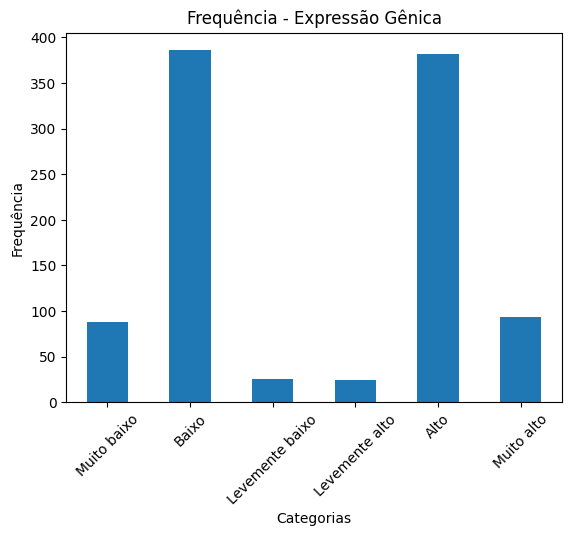

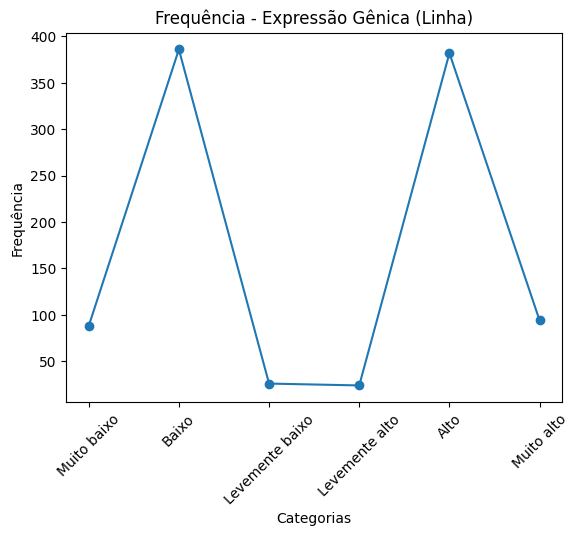

In [16]:
import matplotlib.pyplot as plt

freq_expr = df_final['Grupo_Expressao'].value_counts().sort_index()

plt.figure()
freq_expr.plot(kind='bar')
plt.xlabel('Categorias')
plt.ylabel('Frequência')
plt.title('Frequência - Expressão Gênica')
plt.xticks(rotation=45)
plt.show()

plt.figure()
freq_expr.plot(kind='line', marker='o')
plt.xlabel('Categorias')
plt.ylabel('Frequência')
plt.title('Frequência - Expressão Gênica (Linha)')
plt.xticks(rotation=45)
plt.show()

### Número

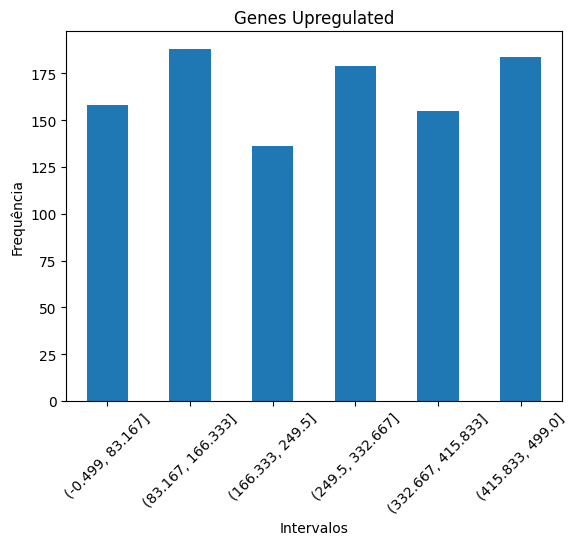

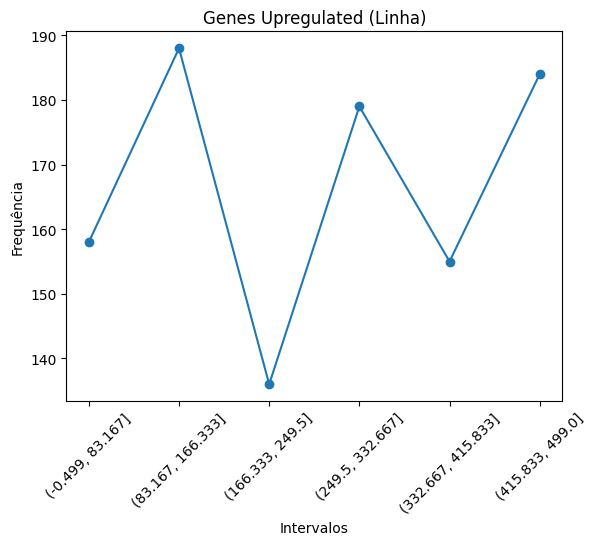

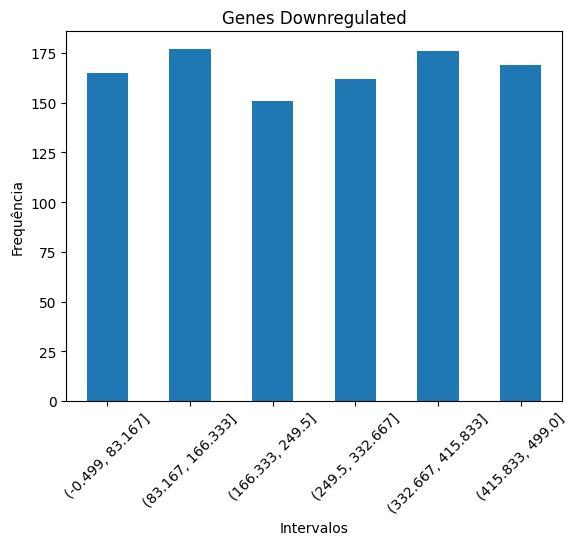

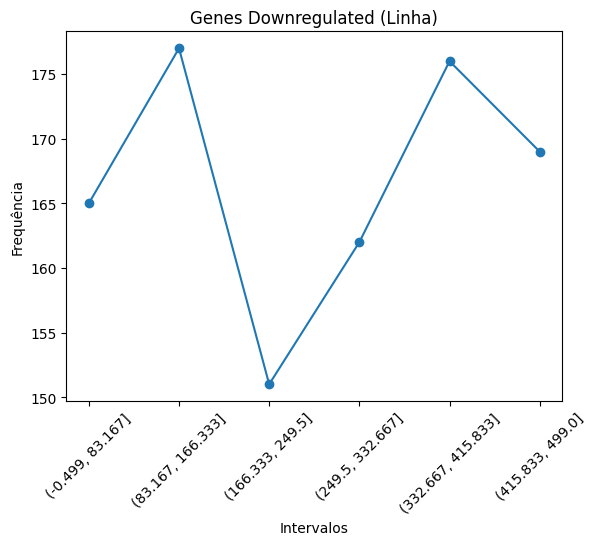

In [19]:
up_bins = pd.cut(df_final['Genes_Upregulated'], bins=6)
freq_up = up_bins.value_counts().sort_index()

plt.figure()
freq_up.plot(kind='bar')
plt.xlabel('Intervalos')
plt.ylabel('Frequência')
plt.title('Genes Upregulated')
plt.xticks(rotation=45)
plt.show()

plt.figure()
freq_up.plot(kind='line', marker='o')
plt.xlabel('Intervalos')
plt.ylabel('Frequência')
plt.title('Genes Upregulated (Linha)')
plt.xticks(rotation=45)
plt.show()

down_bins = pd.cut(df_final['Genes_Downregulated'], bins=6)
freq_down = down_bins.value_counts().sort_index()

plt.figure()
freq_down.plot(kind='bar')
plt.xlabel('Intervalos')
plt.ylabel('Frequência')
plt.title('Genes Downregulated')
plt.xticks(rotation=45)
plt.show()

plt.figure()
freq_down.plot(kind='line', marker='o')
plt.xlabel('Intervalos')
plt.ylabel('Frequência')
plt.title('Genes Downregulated (Linha)')
plt.xticks(rotation=45)
plt.show()

## 06 – Gere os histogramas para as variáveis obtidas nos exercícios 1 e 2.

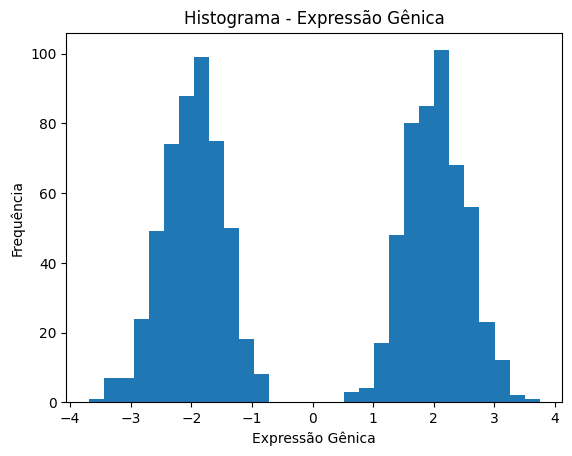

In [20]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df_final['Expressao'], bins=30)
plt.xlabel('Expressão Gênica')
plt.ylabel('Frequência')
plt.title('Histograma - Expressão Gênica')
plt.show()

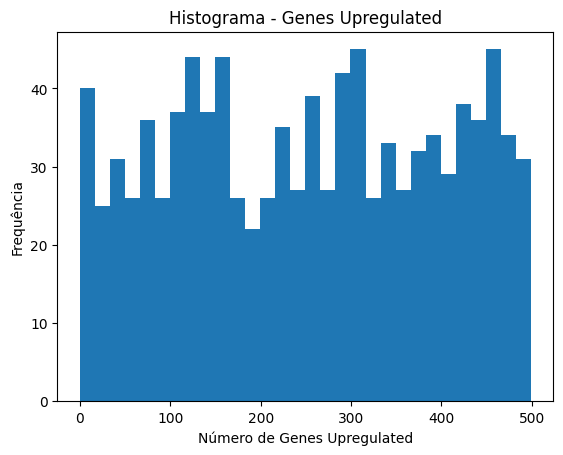

In [21]:
plt.figure()
plt.hist(df_final['Genes_Upregulated'], bins=30)
plt.xlabel('Número de Genes Upregulated')
plt.ylabel('Frequência')
plt.title('Histograma - Genes Upregulated')
plt.show()

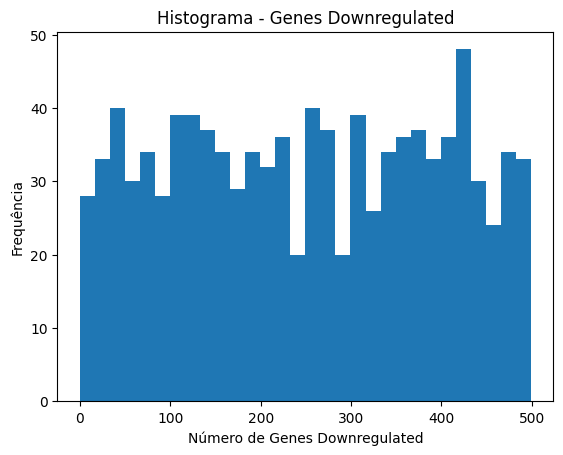

In [22]:
plt.figure()
plt.hist(df_final['Genes_Downregulated'], bins=30)
plt.xlabel('Número de Genes Downregulated')
plt.ylabel('Frequência')
plt.title('Histograma - Genes Downregulated')
plt.show()

## 07 – Gere um gráfico de dispersão para as variáveis obtidas nos exercícios 1 e 2.

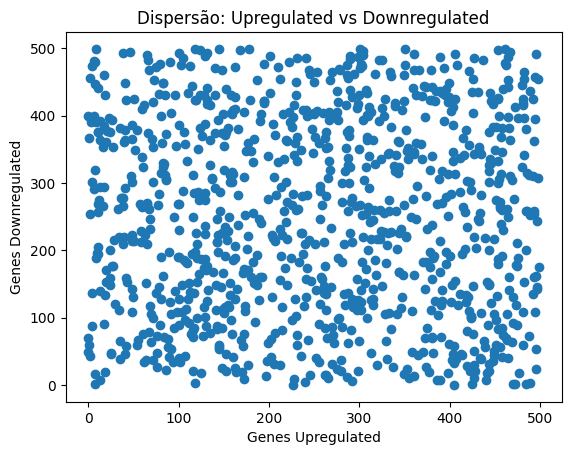

In [23]:
plt.figure()
plt.scatter(df_final['Genes_Upregulated'], df_final['Genes_Downregulated'])
plt.xlabel('Genes Upregulated')
plt.ylabel('Genes Downregulated')
plt.title('Dispersão: Upregulated vs Downregulated')
plt.show()

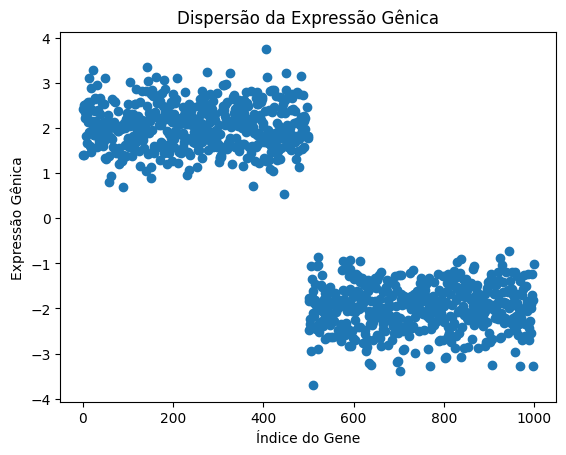

In [24]:
plt.figure()
plt.scatter(range(len(df_final['Expressao'])), df_final['Expressao'])
plt.xlabel('Índice do Gene')
plt.ylabel('Expressão Gênica')
plt.title('Dispersão da Expressão Gênica')
plt.show()

## 08 – Gere o mesmo gráfico do exercício 06, porém, categorizado.

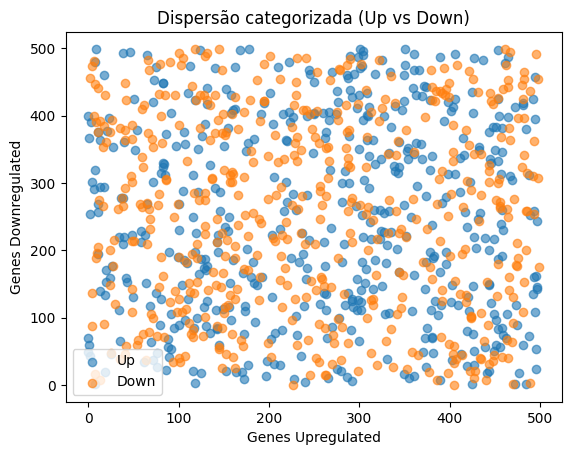

In [25]:
plt.figure()

up = df_final[df_final['Regulacao'] == 'Up']
down = df_final[df_final['Regulacao'] == 'Down']

plt.scatter(up['Genes_Upregulated'], up['Genes_Downregulated'], label='Up', alpha=0.6)
plt.scatter(down['Genes_Upregulated'], down['Genes_Downregulated'], label='Down', alpha=0.6)

plt.xlabel('Genes Upregulated')
plt.ylabel('Genes Downregulated')
plt.title('Dispersão categorizada (Up vs Down)')
plt.legend()
plt.show()

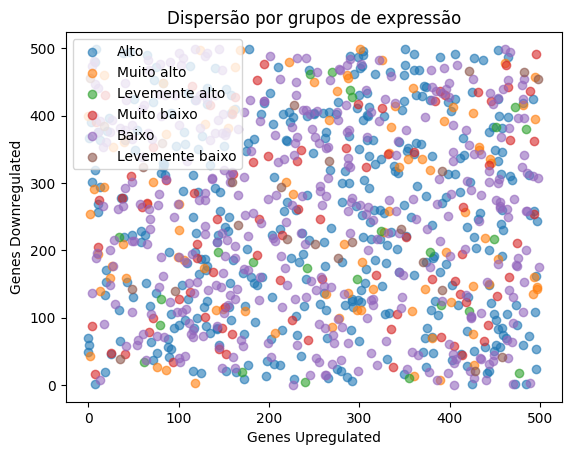

In [26]:
plt.figure()

for grupo in df_final['Grupo_Expressao'].unique():
    subset = df_final[df_final['Grupo_Expressao'] == grupo]
    
    plt.scatter(
        subset['Genes_Upregulated'],
        subset['Genes_Downregulated'],
        label=grupo,
        alpha=0.6
    )

plt.xlabel('Genes Upregulated')
plt.ylabel('Genes Downregulated')
plt.title('Dispersão por grupos de expressão')
plt.legend()
plt.show()

## 09 – Gere o mesmo gráfico do exercício 07, porém, categorizado.

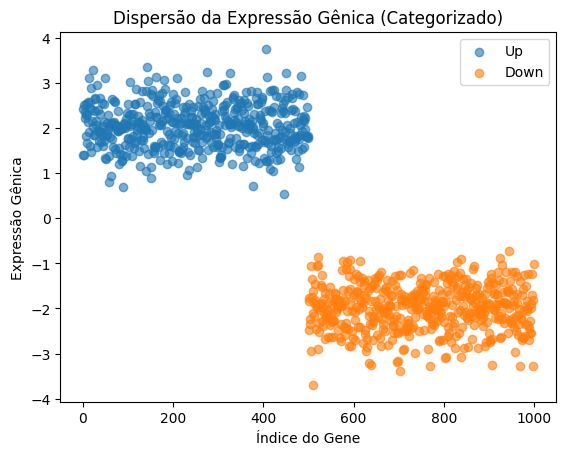

In [27]:
import matplotlib.pyplot as plt

plt.figure()

up = df_final[df_final['Regulacao'] == 'Up']
down = df_final[df_final['Regulacao'] == 'Down']

idx_up = up.index
idx_down = down.index

plt.scatter(idx_up, up['Expressao'], label='Up', alpha=0.6)
plt.scatter(idx_down, down['Expressao'], label='Down', alpha=0.6)

plt.xlabel('Índice do Gene')
plt.ylabel('Expressão Gênica')
plt.title('Dispersão da Expressão Gênica (Categorizado)')
plt.legend()
plt.show()

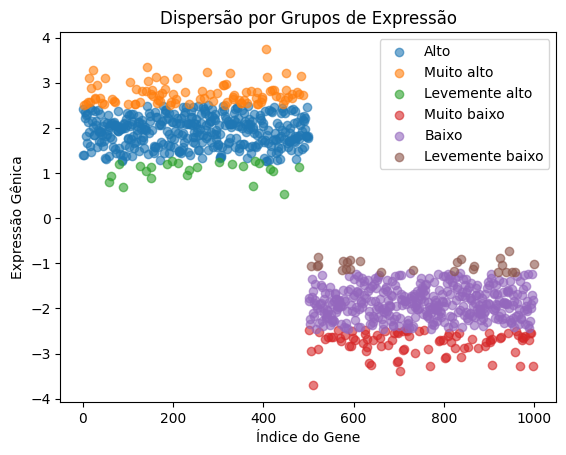

In [28]:
plt.figure()

for grupo in df_final['Grupo_Expressao'].unique():
    subset = df_final[df_final['Grupo_Expressao'] == grupo]
    
    plt.scatter(
        subset.index,
        subset['Expressao'],
        label=grupo,
        alpha=0.6
    )

plt.xlabel('Índice do Gene')
plt.ylabel('Expressão Gênica')
plt.title('Dispersão por Grupos de Expressão')
plt.legend()
plt.show()

## 10 – Indique o tipo da variável:

- Discreta
- Contínua
- Ordinal
- Nominal

| Variável | Valor |
| :--- | :---: |
| # de células positivas||
| % de células positivas||
| Faixa de pH||
| Valor de pH||
| mol/L||
| UFC||
| D.O.||
| Grupo Sanguíneo||
| Sorologia||

In [34]:

# de células positivas = Discreta
# % de células positivas = Contínua
# Faixa de pH = Ordinal
# Valor de pH = Contínua
# mol/L = Contínua
# UFC = Discreta
# D.O. = Contínua
# Grupo Sanguíneo = Nominal
# Sorologia = Nominal